# Hydrologic indices: TWI, SPI, STI
Three classic catchment-scale indices computed from `accumulation` × `slope`:

| Index | Formula | Use |
|-------|---------|-----|
| **TWI** | `ln(SCA / tan(slope))` | Wetness / saturation likelihood (Beven & Kirkby 1979) |
| **SPI** | `SCA × tan(slope)` | Erosion / stream-power proxy |
| **STI** | `(SCA/22.13)^0.6 × (sin(slope)/0.0896)^1.3` | Sediment transport (Moore & Burch 1986) |

All three share the `_area_slope_index` kernel inside `DEM` — caller supplies a precomputed slope
raster (in degrees) or lets the method compute it from `DEM.slope()`.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80


In [2]:
import numpy as np
from pyramids.dataset import Dataset
from digitalrivers import DEM

# Catchment with a clear main-stem chain and tributaries.
rows, cols = 15, 15
z = np.full((rows, cols), 100.0, dtype=np.float32)
for r in range(rows):
    z[r, 7] = float(40 - 2.5 * r)
for c in range(7):
    z[5, c] = float(30 - c)
for c in range(8, cols):
    z[10, c] = float(20 - (c - 8))

ds = Dataset.create_from_array(
    z, top_left_corner=(0.0, 0.0), cell_size=30.0,
    epsg=32618, no_data_value=-9999.0,
)
dem = DEM(ds.raster)
filled = dem.fill_depressions(method="priority_flood")
fd = filled.flow_direction(method="d8")
acc = fd.accumulate()
print(f"Accumulation max: {int(acc.read_array().max())} cells")

2026-05-17 22:36:27 | INFO | pyramids.base.config | Logging is configured.


Accumulation max: 27 cells


## Visualise: DEM + accumulation

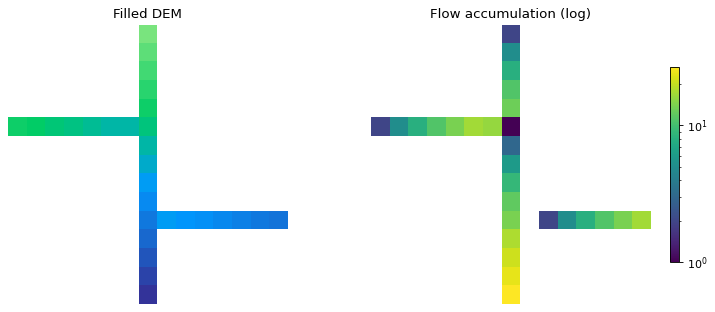

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(filled.values, cmap="terrain", origin="upper")
axes[0].set_title("Filled DEM"); axes[0].axis("off")

acc_arr = acc.read_array()
im = axes[1].imshow(np.where(acc_arr < 1, np.nan, acc_arr), cmap="viridis",
                    norm=LogNorm(vmin=1, vmax=acc_arr.max()), origin="upper")
axes[1].set_title("Flow accumulation (log)"); axes[1].axis("off")
fig.colorbar(im, ax=axes[1], shrink=0.7)
fig.tight_layout()
plt.show()


## Topographic Wetness Index (TWI)

TWI = ln(SCA / tan(slope)). High TWI marks cells likely to saturate first — large upstream area
AND low slope. The classic stream-bottom cells score highest.

In [4]:
twi = filled.twi(acc).read_array()
valid_twi = twi[twi != -9999.0]
valid_twi = valid_twi[np.isfinite(valid_twi)]
print(f"TWI range:     [{valid_twi.min():.3f}, {valid_twi.max():.3f}]")
print(f"Mean TWI:      {valid_twi.mean():.3f}")

TWI range:     [5.886, 13.605]
Mean TWI:      8.949


## Stream Power Index (SPI)

SPI = SCA × tan(slope). Proportional to the rate at which overland flow does work — a proxy for
erosion risk. Steep cells with large upstream area score highest.

In [5]:
spi = filled.spi(acc).read_array()
valid_spi = spi[(spi != -9999.0) & np.isfinite(spi)]
print(f"SPI range:     [{valid_spi.min():.3f}, {valid_spi.max():.3f}]")
print(f"Mean SPI:      {valid_spi.mean():.3f}")

# SPI must be ≥ 0 (SCA and tan(slope) both non-negative on valid cells)
assert (valid_spi >= 0).all()

SPI range:     [0.000, 60.000]
Mean SPI:      2.059


## Sediment Transport Index (STI)

STI = (SCA / 22.13)^0.6 × (sin(slope) / 0.0896)^1.3 — the per-unit-area form of the RUSLE LS
factor. Predicts where flow will transport sediment rather than deposit it.

In [6]:
sti = filled.sti(acc).read_array()
valid_sti = sti[(sti != -9999.0) & np.isfinite(sti)]
print(f"STI range:     [{valid_sti.min():.3f}, {valid_sti.max():.3f}]")
print(f"Mean STI:      {valid_sti.mean():.3f}")

assert (valid_sti >= 0).all()

STI range:     [0.000, 7.916]
Mean STI:      0.323


## Visualise: TWI / SPI / STI

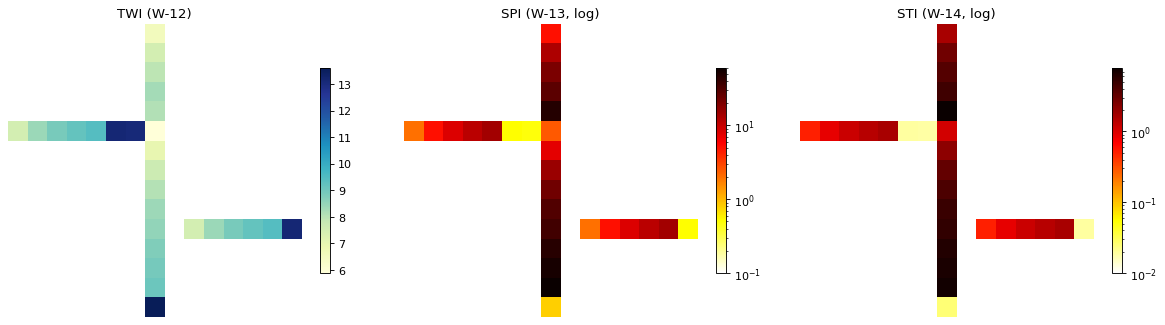

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def _mask(a):
    return np.where((a == -9999.0) | (~np.isfinite(a)), np.nan, a)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
twi_show = _mask(twi)
im = axes[0].imshow(twi_show, cmap="YlGnBu", origin="upper")
axes[0].set_title("TWI"); axes[0].axis("off")
fig.colorbar(im, ax=axes[0], shrink=0.7)

spi_show = _mask(spi)
spi_show = np.where(spi_show > 0, spi_show, np.nan)
im = axes[1].imshow(spi_show, cmap="hot_r", origin="upper",
                    norm=LogNorm(vmin=0.1, vmax=np.nanmax(spi_show)))
axes[1].set_title("SPI (log)"); axes[1].axis("off")
fig.colorbar(im, ax=axes[1], shrink=0.7)

sti_show = _mask(sti)
sti_show = np.where(sti_show > 0, sti_show, np.nan)
im = axes[2].imshow(sti_show, cmap="hot_r", origin="upper",
                    norm=LogNorm(vmin=0.01, vmax=np.nanmax(sti_show)))
axes[2].set_title("STI (log)"); axes[2].axis("off")
fig.colorbar(im, ax=axes[2], shrink=0.7)
fig.tight_layout()
plt.show()


## Reusing a precomputed slope raster

All three methods accept `slope_deg=` as a kwarg to skip recomputation when you already have a
slope raster handy.

In [8]:
slope_ratio = filled.slope().read_array()  # m/m
slope_deg_arr = np.degrees(np.arctan(np.where(
    np.isfinite(slope_ratio), slope_ratio, 0.0,
)))
slope_deg = Dataset.create_from_array(
    slope_deg_arr.astype(np.float32),
    geo=filled.geotransform, epsg=filled.epsg, no_data_value=-9999.0,
)
twi_reused = filled.twi(acc, slope_deg=slope_deg).read_array()
np.testing.assert_allclose(
    twi_reused[twi_reused != -9999.0],
    twi[twi != -9999.0],
    atol=1e-3,
)
print("TWI with reused slope matches default-computed TWI.")

TWI with reused slope matches default-computed TWI.


## Summary

Three classic indices in three one-line calls. The shared `_area_slope_index` kernel handles
no-data masking, slope-floor clamping (to avoid `log(0)` on flats), and float32 output wrapping.